![Banner](https://raw.githubusercontent.com/crunchdao/quickstarters/refs/heads/master/competitions/structural-break-real-time/assets/banner.webp)

# ADIA Lab Structural Break Challenge: Real-Time Edition

**A hands-on tutorial for participants.**

Welcome! In this notebook you will:

1. Learn **what the challenge is about**, in plain English.
2. See **what your code has to produce**, for every time series.
3. Understand **how submissions are scored** (the Time-Stratified AUC).
4. Walk through a **minimal working submission**: a simple streaming detector that you can submit as-is, then improve step by step.
5. Test your submission **locally**, so you can iterate quickly before uploading.

No prior experience with structural-break detection is required. If you can read Python and know what a time series is, you are in the right place.

## What is a structural break?

A **structural break** in a time series is a point in time at which the *rules* that generate the data change permanently. Before that moment the series follows one pattern; from that moment on, it follows a different one.

A simple example of a mean-shift break: the series oscillates around a lower mean before the break and around a higher one after.

![Example: a time series with a structural break. The dashed line marks the break.](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/competitions/structural-break-real-time/quickstarters/baseline/images/dgp_example.png)

Examples from the real world:

- **Finance.** A trading strategy that used to produce small, steady profits starts producing small, steady losses after some market regime change.
- **Industry.** A sensor on a machine used to oscillate around a fixed mean with fixed variance; after a bearing starts wearing out, the oscillations become larger.
- **Climate.** The average temperature in a region is stable for decades, then shifts upward as the local climate changes.
- **Healthcare.** A patient's resting heart-rate is steady for months, then drifts upward after a new medication is introduced.

The simplest kind of break is a *mean shift*: the average value of the series suddenly moves. <br />
But breaks can also be changes in variance (the series becomes noisier), in distribution (the shape of the noise changes), or in dependence structure (how each observation relates to the previous ones).

## Anatomy of a time series in this challenge

Each time series you receive is divided into two parts:

- A **historical segment** (1,000 to 5,000 observations), given in full at the start. This is the *reference* behaviour -- guaranteed to contain **no break**.
- An **online segment** (10 to 1,000 observations), revealed to your code **one observation at a time**. This is the part under scrutiny.

![Time series structure: historical segment (blue), online segment before the break (green), online segment after the break (red). The dashed vertical line marks the start of the online segment; the dotted line marks the break.](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/competitions/structural-break-real-time/quickstarters/baseline/images/competition_overview.png)

In the online segment, one of two things happens:

- Either a **break occurs** at some unknown time step $\tau$, and the behaviour after $\tau$ differs from the historical segment.
- or **No break occurs** at all -- the series just continues to behave like its historical reference.

Your job is to figure out, live, whether a break has already happened.

> **‼ Contrast with the 2025 edition**
> ---
> If you participated last year, the break (when present) was always at the known boundary between the two segments, and you returned a single score per series. This year the break location is unknown and can be anywhere in the online segment, and you return one score **per online time step**.

## What your code must output

At every online observation $t$, your code produces **one score $s_t \in [0, 1]$**. The score expresses your cumulative belief that a break has **already occurred somewhere up to and including step $t$**:

- $s_t = 0$: you are fully confident **no break** has happened yet.
- $s_t = 1$: you are fully confident a break **has already happened**.
- Anything in between is a soft confidence.

The **ideal score sequence** looks like a step function:

- Before the break, $s_t = 0$.
- From the break time $\tau$ onward, $s_t = 1$.

If there is no break at all, the ideal sequence is zero throughout.

Your real submission will not produce a perfect step. A good submission is one that, on average, increases sharply around $\tau$ and stays low otherwise.

The figure below contrasts a participant's score (solid) against the ideal step (dashed). The shaded area between them reflects how early and cleanly the break was picked up -- smaller is better.

![Evaluation example: participant scores (solid) vs ideal step function (dashed). A good submission keeps the shaded area small.](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/competitions/structural-break-real-time/quickstarters/baseline/images/evaluation_example.png)

## How submissions are scored: Time-Stratified AUC

All submissions are graded with a single metric, **Time-Stratified AUC** (TS-AUC). The intuition is:

1. **At each online time step $t$**, look across *all series alive at that step*. Some of those series have already had their break ($\text{label}_t = 1$); the others have not ($\text{label}_t = 0$).
2. **Compute an ordinary AUC** at that step: how well do your scores rank the series with a break above thhose without a break?
3. **Take a weighted average** of those per-step AUCs across all time steps.

The formula is:

$$
\text{TS-AUC} \;=\; \frac{\sum_t w(t)\,\text{AUC}(t)}{\sum_t w(t)},
\qquad w(t) = n_\text{pos}(t)\cdot n_\text{neg}(t)
$$

where $w(t)$ is the number of positive-negative pairs at step $t$ (steps with only one kind of series contribute nothing).

**Range and reference values:**

- TS-AUC = 1.0 means perfect detection at every step.
- TS-AUC = 0.5 means random-guessing (and is exactly what you get if your score depends only on $t$ -- for example, always returning $s_t = t / T$).
- Higher is better.

### A tiny worked-out example

Imagine just three series, each of online length 4. Below are the scores produced by a participant. A *check-mark* marks which online steps are post-break (label 1); the rest are pre-break (label 0).

| series           | $t=0$ | $t=1$  | $t=2$  | $t=3$  |
| ---------------- | ----- | ------ | ------ | ------ |
| A (break at t=2) | 0.10  | 0.15   | 0.60 ✓ | 0.80 ✓ |
| B (break at t=1) | 0.05  | 0.30 ✓ | 0.55 ✓ | 0.70 ✓ |
| C (no break)     | 0.02  | 0.10   | 0.20   | 0.40   |

At $t=0$: all three are pre-break -- no positive/negative pair, so this step contributes nothing. At $t=1$: B is positive, A and C are negative; the AUC at this step measures whether B's score (0.30) is higher than A's (0.15) and C"s (0.10) -- it is, so AUC(t=1) = 1.0.
And so on for $t=2, 3$. The final TS-AUC is the weighted average of these per-step AUCs.

Note: because the metric only compares scores **across series at the same time step**, a score that grows purely with $t$ (like $s_t = t/T$) gains nothing. This rewards *genuine* change-detection.

# Getting set up

The first steps to get started are:

1. Get the setup command from the competition page below.
2. Paste the token into the cell that follows and run it.

### >> https://hub.crunchdao.com/competitions/structural-break-real-time/submit/notebook

![Reveal token](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/animations/reveal-token.gif)


In [1]:
%pip install crunch-cli --upgrade --quiet --progress-bar off
!crunch setup-notebook structural-break-real-time 6PLzF2rwz8EQ7YwYLPRuo81p

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
'crunch' is not recognized as an internal or external command,
operable program or batch file.


# Your submission

A submission to this competition consists of two Python functions:

- `train(datasets, model_directory_path)`: optional; fit any model you want on the training data and save the result to disk.
- `infer(datasets, model_directory_path)`: a **generator** that yields one score per online observation, in order.

We will first import dependencies and load the data, then walk through each function.

In [ ]:
import math
import os
from typing import Iterable, List, Optional, Tuple

# Import your dependencies.
import joblib
import numpy as np
import pandas as pd
import pywt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import ks_2samp, skew
from scipy.signal import welch

In [3]:
import crunch

# Load the Crunch Toolings (data loader, local tester, submitter).
crunch_tools = crunch.load_notebook()

loaded crunch tools for module: <module '__main__'>

cli version: 12.0.1
available ram: 7.42 gb
available cpu: 16 core
----


## Looking at the data

`crunch_tools.load_data()` returns two objects:

- `train_data`: the training set. <br />
  Each element is a tuple `(dataset_id, x_historical, x_online, tau_index)` where:
  - `dataset_id` is an integer identifier,
  - `x_historical` is a 1-D numpy array of the historical segment,
  - `x_online` is a 1-D numpy array of the full online segment,
  - `tau_index` is the index within `x_online` at which the break happens, or `None` if the series has no break.
- `test_data`: the test set. <br />
  with the same layout but *without* `tau_index`, and with `x_online` that can only be **iterated once** in the cloud environment.

<br />

> **📝 Note**
> ---
> Locally (inside this notebook) you can re-read the test series as many times as you like while developing.

In [4]:
# Load the data.
train_data, test_data = crunch_tools.load_data()

data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_train.parquet: already exists, file length match
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\X_test.reduced.parquet: already exists, file length match
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_train.parquet: already exists, file length match
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test.reduced.parquet: already exists, file length match
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws

### A single training series

Let us look at one training series with a break, to get a feel for the
data.


In [5]:
# Pick a training series that has a break.
for dataset_id, x_hist, x_online, tau in train_data:
    if tau is not None and 50 <= tau <= len(x_online) - 50:
        break

x_hist   = np.asarray(x_hist)
x_online = np.asarray(x_online)

print(f"      series id: {dataset_id}")
print(f"historical size: {len(x_hist)}")
print(f"    online size: {len(x_online)}")
print(f"   break at tau: {tau}   (None means no break)")

      series id: 0
historical size: 1192
    online size: 416
   break at tau: 72   (None means no break)


## A baseline strategy: streaming EWMA z-score

Now that we have seen the data, we can design a simple detector. The baseline uses a classic idea from statistical process control:

1. Summarize the historical segment by its **mean** $\mu_H$ and **standard deviation** $\sigma_H$.
2. As online observations arrive, maintain an **exponentially-weighted moving average (EWMA)** $\bar{x}_t$ of the online values.
3. Compare $\bar{x}_t$ to the historical mean in *standard-deviation units*:

   $$
   z_t \;=\; \frac{\bar{x}_t - \mu_H}{\sigma_H / \sqrt{n_\text{eff}}}
   $$

   where $n_\text{eff}$ is the effective sample size of the EWMA.
4. Map $|z_t|$ to a score in $[0, 1]$ with a **tanh squash**:

   $$
   s_t \;=\; \tanh(|z_t|)
   $$

### Why this is a reasonable baseline

- **It is truly streaming.** <br />
  Each new point updates the EWMA with a constant amount of work; nothing is recomputed from scratch. <br />
  This is important -- with 10,000 series and up to 1,000 online steps each, a submission that re-fits at every step runs out of time.
- **It does not saturate.** <br />
  The score stays strictly below 1, so the detector can still distinguish *very strong* evidence from *strong* evidence. 
- **It only reacts to mean shifts.** <br />
  Variance and shape changes are not captured well -- an opportunity for you to improve.

<br />

> **📝 Note (on what this baseline ignores)**
> ---
> It treats each series independently, which is exactly how it must -- the online segments arrive one at a time and there is no cross-series information available in production. <br />
> Incrementality is therefore not optional; it is built into the evaluation protocol.

### Alternative: two-sample KS-test scoring

The note above flags it directly: the EWMA baseline only reacts to **mean** shifts. The classic tool for catching *any* distributional change -- mean, variance, or shape -- is the two-sample **Kolmogorov-Smirnov (KS) test**:

$$
D_t \;=\; \sup_{x} \bigl| F_H(x) - F_t(x) \bigr|
$$

where $F_H$ is the empirical CDF of the historical segment and $F_t$ is the empirical CDF of the online segment observed so far. We turn the test's $p$-value into a score:

$$
s_t \;=\; 1 - p_t
$$

### Why this is worth trying, and what it costs

- **It catches what EWMA can't.** <br />
  A break that changes variance or shape while leaving the mean roughly unchanged scores near zero under EWMA, but shows up directly in $D_t$.
- **It is not O(1) per step.** <br />
  Unlike the EWMA update, $F_t$ must be rebuilt from the full online-so-far sample at every step -- naively $O(t \log t)$ per point, so this is meaningfully slower to run locally than the baseline, and would need a streaming-sketch approximation to stay within the platform's compute budget at full scale.

Set `SCORING_METHOD = "ks_test"` below to switch `infer()` over to this scorer, then re-run **Local testing** and **Computing TS-AUC locally** to compare it against the EWMA baseline directly.


### My own experiment: combining multiple views

A single KS test on raw values still misses one thing: **dependence-structure**
breaks, where the mean and variance stay the same but how points relate to their
*neighbors* changes (e.g. independent noise becoming autocorrelated). This runs the
same KS comparison on three different transforms of the series and takes the max:

- **Raw values** -- catches location and shape shifts (the original KS test above).
- **Absolute deviation from the historical mean** -- catches variance/scale shifts.
- **First differences** -- catches dependence/volatility-structure shifts, since
  differencing changes the increment distribution when autocorrelation changes even
  if the marginal distribution doesn't.

Verified on synthetic data with a pure autocorrelation break (same mean, same
variance, only the dependence structure changes): the raw-values view alone scored
~0.39, while the first-differences view caught it clearly at ~0.71. Set
`SCORING_METHOD = "ks_multi"` to try it.

**Known limitation:** all three views share `KAPPA_KS`, calibrated only against the
raw-values view's no-break behavior -- the absolute-deviation and first-difference
transforms likely have somewhat different null distributions, so their false-positive
floors aren't separately calibrated yet. Logged as open work in `EXPERIMENTS.md`.

### Feature engineering: rolling-window statistics instead of whole-sample KS

All three methods above compare the **entire online-so-far sample** against the
historical segment with a KS test, and all three plateau at TS-AUC ~0.50-0.52 (see
`EXPERIMENTS.md`). That's a strong signal the *KS-on-a-growing-sample* framing itself
is the bottleneck, not the choice of transform: as `t` grows, `online_so_far` is
dominated by pre-break points, which dilutes the post-break signal exactly when the
sample is largest and the test should be most powerful.

Instead of testing the whole online-so-far sample, compute a small set of **rolling
statistics over a fixed trailing window** of the last `W` points, and compare each
one to its own null distribution built by sliding the same window across the
historical segment:

- **Rolling mean** -- location shift.
- **Rolling std** -- variance/scale shift.
- **Rolling skew** -- shape shift.
- **Lag-1 autocorrelation** -- dependence-structure shift.
- **Mean absolute first difference** -- local volatility of increments.

For each feature, compute `z = (online_value - hist_mean) / hist_std` using the
mean/std of that feature's distribution across all historical windows, then combine
via `max(|z|)` (same combining idea as `ks_multi`) and squash with `tanh`.

This fixes the dilution problem structurally: a break that happened `W` points ago is
fully visible in the trailing window regardless of how long the total online segment
has grown, whereas a whole-sample KS test keeps diluting it. Set
`SCORING_METHOD = "feature"` to try it.

**Result:** TS-AUC 0.5026 -- no better than the KS family. Verified on synthetic
mean/variance/autocorrelation breaks first (AUC 0.96-0.99), and the pipeline itself
was cleared with an oracle-scoring sanity check (using ground truth as the score gives
a perfect TS-AUC of 1.0). The per-series score does ramp up correctly after the true
break; the failure is in **cross-sectional ranking at a fixed time step**, not in
per-series signal extraction. See `EXPERIMENTS.md` row 5 and the reframed §5 for the
full writeup.

### Tier 2: CUSUM and Page-Hinkley -- cumulative evidence instead of a moving window

EWMA, `ks_test`, `ks_multi`, and `feature` are all, in one way or another, **"instant"
or windowed** detectors: a break's evidence eventually decays out of an EWMA's
effective window, or falls out of `feature`'s fixed `FEAT_WINDOW`, or gets diluted by
a growing whole-sample KS test. Since all four landed at the same ~0.50-0.52 TS-AUC
ceiling despite being structurally very different, the next thing worth isolating is
whether the *cumulative, non-forgetting* family of detectors behaves differently.

**CUSUM (two-sided cumulative sum control chart).** Standardize each online point
against the historical mean/std, then accumulate one-sided cumulative sums that only
grow when the standardized residual persistently exceeds a small slack `k` (in
either direction):

$$
g^+_t = \max(0,\; g^+_{t-1} + z_t - k), \qquad
g^-_t = \max(0,\; g^-_{t-1} - z_t - k), \qquad
z_t = \frac{x_t - \mu_H}{\sigma_H}
$$

$$
s_t = \tanh\!\left(\frac{\max(g^+_t, g^-_t)}{\kappa_\text{CUSUM}}\right)
$$

Unlike EWMA, `g^+`/`g^-` never decay on their own -- they only reset via the `max(0, ...)`
floor when the series is back in line with the historical mean. A persistent post-break
shift keeps accumulating evidence indefinitely instead of it aging out.

**Page-Hinkley test.** The classical sequential change-detection test, closely related
to CUSUM but built from a running mean of the *online* stream itself rather than a
fixed historical reference, so it adapts to slow drift without a hard-coded target:

$$
m_t = \frac{1}{t}\sum_{i=1}^{t} x_i, \qquad
PH_t = \sum_{i=1}^{t} \bigl(x_i - m_i - \delta\bigr), \qquad
M_t = \min_{i \le t} PH_i
$$

$$
s_t = \tanh\!\left(\frac{PH_t - M_t}{\kappa_\text{PH}}\right)
$$

`delta` is a small allowed drift (like CUSUM's slack `k`); `PH_t - M_t` measures how far
the cumulative sum has risen from its historical minimum, which grows steadily once a
sustained upward shift begins and is bounded near zero otherwise.

Both are still O(1) per step. Set `SCORING_METHOD = "cusum"` or `"page_hinkley"` to try
them.

### Tier 3: a learned classifier over engineered features

Six structurally different hand-crafted detectors (`ewma`, `ks_test`, `ks_multi`,
`feature`, `cusum`, `page_hinkley`) all converged on TS-AUC ~0.50-0.52 despite each
one individually scoring well (0.6-1.0 AUC) on synthetic breaks -- strong evidence that
real breaks in this dataset are subtler than any single hand-tuned statistic can
isolate on its own, not that the detection paradigms themselves are wrong. The natural
next step is to stop hand-picking *one* statistic and instead let a model learn how to
combine several.

**Feature vector** (14 features per online step, all computed causally from data up to
and including that step -- see the streaming-protocol note below for a feature that
had to be dropped and why):
- `z_raw` -- the current point's z-score vs. the historical mean/std.
- `roll_mean`, `roll_std`, `roll_skew`, `roll_autocorr`, `roll_mad_diff` -- the same
  five rolling-window statistics from the `feature` scorer (trailing window of
  `FEAT_WINDOW` points).
- `z_mean`, `z_std`, `z_skew`, `z_autocorr`, `z_mad_diff` -- each of those, z-scored
  against its own historical window-distribution (same idea as `feature`'s `max|z|`,
  but kept as five separate inputs instead of collapsed to one number).
- `cusum`, `page_hinkley` -- the full cumulative statistics from the Tier-2 detectors.
- `t_idx` -- the online step index (points seen so far).

**Model.** `sklearn.ensemble.HistGradientBoostingClassifier` (no extra dependency
needed -- `lightgbm` isn't installed in this environment and the local `xgboost` has a
broken native/Python version mismatch). Trained once in `train()` on every training
series' online segment, with `label_t = 1` iff `t >= tau`.

**Why this changes the framing entirely:** every earlier method picked *one* score
formula and hoped it generalized. A gradient-boosted tree can instead learn, e.g.,
"large `roll_std` shift matters more when `roll_skew` is also elevated," or discount
`cusum` under conditions where it's historically been noisy for this kind of series --
interactions no single hand-tuned `tanh(...)` formula can express.

**Streaming-protocol correction (important if you're extending this) -- two separate
bugs found and fixed during development:**

1. The first implementation buffered a series' entire `x_online` up front (to batch
   `predict_proba` calls per series for speed, and to compute a `t_frac` feature --
   fraction of online length elapsed). This crashes the local tester with
   `ProtocolError: previous value not yield-ed` -- `x_online` is a lazy, single-pass
   generator gated on `infer()` yielding a score for the current point before it
   releases the next one, exactly as this notebook's own `infer()` docstring warns
   earlier. Fix: consume one point at a time, yield after each, call `predict_proba`
   per point (much slower per call, but the only protocol-correct option).
2. `t_frac` itself had to be dropped, not just deferred to per-point computation -- it
   fundamentally requires knowing the total online length *in advance*, which the
   streaming contract never provides. This wasn't just a performance shortcut; it was
   using information the real submission would not have available in the cloud
   environment, so it had to go regardless of the batching fix.

**Result, corrected:** the very first (buggy, pre-fix) version's validation TS-AUC of
0.6518 turned out to be substantially inflated by `t_frac` -- retraining on the
identical data with `t_frac` removed drops validation TS-AUC to **0.536-0.545**
depending on `max_iter`. Permutation importance confirms `roll_std`/`z_std` still
dominate by a wide margin (variance shifts remain the most learnable real signal),
`t_idx` is a modest third contributor, and `cusum`/`page_hinkley`/autocorrelation
contribute almost nothing -- consistent with the standalone Tier 1/2 detectors' own
relative performance. `max_iter=100` was chosen over `HistGradientBoostingClassifier`'s
usual higher settings specifically because `predict_proba`'s per-call latency scales
with it, and `infer()` must call it once per streamed point -- `max_iter=300` pushed
local testing (~350K points) past 60 minutes; `max_iter=100` keeps it to ~7 minutes for
a TS-AUC difference of about 0.01. **0.536-0.545 is still a genuine improvement over
every Tier 1/2 method's ~0.50-0.52 ceiling**, just a smaller one than first appeared.
The real number on the reduced test set (not just the training-set validation split)
is in `EXPERIMENTS.md`'s experiment log. Set `SCORING_METHOD = "learned"` to use it.

### Tier 3.5: adding wavelet and spectral decomposition features

The 14-feature classifier above (row 8 in `EXPERIMENTS.md`, TS-AUC 0.5194) is built
entirely from time-domain summary statistics -- mean, std, skew, autocorrelation,
cumulative sums. All of them describe a window's *values* directly. None of them
describe how a window's energy is distributed *across scales or frequencies* --
information a break that changes short-range dependence or noise structure (not just
level or variance) can carry even when the plain summary statistics barely move.

**Six new features per online step, added to the existing 14 (20 total in
`LEARNED_FEATURE_COLS`):**
- `wave_e0`, `wave_e1`, `wave_e2` -- log(1 + energy) in each sub-band of a discrete
  wavelet transform (`WAVELET = "haar"`, `WAVELET_LEVEL = 2`, `mode="periodization"`)
  of the trailing `FEAT_WINDOW`-point window. Sub-band 0 is the coarse approximation;
  1-2 are progressively finer detail (higher-frequency) bands. `haar` was chosen over
  smoother wavelets (`db4`, etc.) because it's the most temporally localized --
  a single up/down step -- which tends to respond fastest to abrupt jumps and
  variance shifts, the kind of break this task cares about.
- `wave_entropy` -- Shannon entropy of the normalized per-band energy distribution.
  Catches energy being *redistributed* across scales even when total energy is
  unchanged (a case `wave_e0..e2` alone could miss if band shifts partially cancel).
- `spec_entropy`, `spec_centroid` -- Shannon entropy and centroid of the window's
  Welch power spectral density. A different basis (Fourier vs. wavelet) with
  different sensitivity, catching frequency-content shifts the DWT bands might miss.

These are used as **raw values, not z-scored** against a historical null (unlike
`roll_mean`/`roll_std`/etc.'s `z_mean`/`z_std`/etc. counterparts) -- `HistGradientBoostingClassifier`
is a tree model that thresholds features directly, so it doesn't need pre-normalized
inputs the way the hand-crafted `tanh(...)` scorers do. The FEAT_WINDOW-length
transform recomputed at every step stays cheap regardless: ~0.1-0.2ms per window in
isolation (benchmarked), small relative to the classifier's own `predict_proba` call
(~1.2ms/call at `max_iter=100`).

**Verified on synthetic data before touching real data** (same discipline as every
prior method in this notebook): on an injected variance-only break (mean unchanged,
std tripled at a known point), `wave_e1`/`wave_e2` visibly shifted (e.g. one run:
1.95 -> 3.90 and 2.75 -> 4.72) alongside the expected `roll_std` shift, confirming the
new features carry real signal rather than just duplicating `roll_std` under another
name. The vectorized (training) and streaming (inference) implementations were checked
against each other across three scenarios -- a plain random series, a series with an
injected break, and a short online segment below `FEAT_WINDOW` -- and matched to
floating-point precision (~1e-14) in all three, ruling out the kind of silent
train/inference drift that bit the original 14-feature set's rolling-window alignment.

**Training-time cost -- parallelization tried and reverted.** Unlike the closed-form
O(1)-per-step statistics, DWT/Welch have no pandas-rolling shortcut, so the bulk
(training-side) extraction is an explicit per-window Python loop, benchmarked at
~130ms per average-length series (~22 minutes serially across all 10,000 training
series). This was initially parallelized across series with `joblib.Parallel(n_jobs=-1)`,
but that crashes under this competition's local-test harness: `crunch`'s
`monkey_patches.joblib_parallel_initializer` unconditionally patches
`joblib.Parallel.__init__` so every worker process re-imports the user's code from a
`main.py` file on disk (needed for pickled closures to resolve correctly across
process boundaries) -- this notebook-based workflow has no `main.py`, so every worker
fails immediately with `FileNotFoundError` and the pool dies with
`TerminatedWorkerError`. This is a harness-level constraint (see
`crunch/monkey_patches.py`), not a bug in the feature code, and not something to route
around with a different backend or `n_jobs` value -- `train()` extracts features
serially instead. See `EXPERIMENTS.md` for the measured wall-clock time and result.

Set `SCORING_METHOD = "learned"` (unchanged) to use this extended feature set --
`LEARNED_FEATURE_COLS` in the hyperparameters cell now lists all 20 features.

In [ ]:
# Detector hyperparameters and the scoring-method switch, defined once
# at notebook level so infer() and the local-inspection helpers (added
# later in this notebook) always agree.
SCORING_METHOD = "learned"   # "ewma", "ks_test", "ks_multi", "feature", "cusum", "page_hinkley", or "learned" -- see the sections above.
ALPHA = 0.05    # EWMA decay in (0, 1]; higher = faster response but more noise. Effective window ~ 1/alpha = 20 points.
KAPPA = 3.0     # tanh scale; |z| = 3 -> score ~ 0.76
KAPPA_KS = 3.7  # tanh scale for the KS statistic, calibrated to match EWMA's no-break floor
FEAT_WINDOW = 30    # rolling-window size (points) for the "feature" and "learned" scorers
KAPPA_FEAT = 3.0    # tanh scale for the feature scorer's max|z|; same interpretation as KAPPA
CUSUM_K = 0.5       # CUSUM slack, in standard-deviation units; absorbs noise so g+/g- don't grow from pure noise
KAPPA_CUSUM = 5.0   # tanh scale for the CUSUM statistic
PH_DELTA = 0.5      # Page-Hinkley allowed drift, in raw units of the (typically standardized) series
KAPPA_PH = 5.0      # tanh scale for the Page-Hinkley statistic
WAVELET = "haar"        # simplest/most localized wavelet -- best at catching abrupt jumps and variance shifts
WAVELET_LEVEL = 2        # -> 3 DWT sub-bands (1 approx + 2 detail) for a FEAT_WINDOW-length periodization-mode transform
N_WAVE_FEATS = WAVELET_LEVEL + 1 + 1   # sub-band log-energies + one band-energy-entropy scalar
WELCH_NPERSEG = 16       # Welch PSD segment length for the spectral features below; must be <= FEAT_WINDOW
LEARNED_FEATURE_COLS = [
    "z_raw", "roll_mean", "roll_std", "roll_skew", "roll_autocorr", "roll_mad_diff",
    "z_mean", "z_std", "z_skew", "z_autocorr", "z_mad_diff",
    "cusum", "page_hinkley", "t_idx",
    "wave_e0", "wave_e1", "wave_e2", "wave_entropy", "spec_entropy", "spec_centroid",
]  # feature order shared between train()'s vectorized extraction and infer()'s streaming extraction.
   # NOTE: t_frac (fraction of online length elapsed) was dropped -- it requires
   # knowing the total online length in advance, which infer() cannot do under the
   # true streaming contract (x_online is a lazy, single-pass generator; the runner
   # raises ProtocolError if you try to drain it before yielding each score). t_idx
   # (points seen so far) is kept since it's genuinely causal.
   # wave_e0..e2/wave_entropy/spec_entropy/spec_centroid: a wavelet (DWT) and
   # spectral (Welch PSD) decomposition of each rolling window, on top of the
   # plain summary statistics above -- these react to *how energy is
   # distributed across scales/frequencies* within a window, which a break
   # that changes variance structure or short-range dependence (not just the
   # mean) can shift even when roll_mean/roll_std barely move. See the
   # markdown cell above and EXPERIMENTS.md for the verification and result.

In [ ]:
def _window_stats(w: np.ndarray) -> Tuple[float, float, float, float, float]:
    """
    Five rolling-window features for a 1-D window `w`: mean, std, skew,
    lag-1 autocorrelation, and mean absolute first difference. Shared
    between infer()'s "feature" branch and the local plotting helper
    (feature_scores()) so they never drift apart.
    """
    mean = float(w.mean())
    std = float(w.std(ddof=1)) if len(w) > 1 else 0.0

    sk = float(skew(w)) if len(w) > 2 and std > 1e-12 else 0.0

    if len(w) > 2:
        w0, w1 = w[:-1], w[1:]
        c0, c1 = w0.std(), w1.std()
        if c0 > 1e-12 and c1 > 1e-12:
            autocorr = float(np.corrcoef(w0, w1)[0, 1])
        else:
            autocorr = 0.0
    else:
        autocorr = 0.0

    mad_diff = float(np.abs(np.diff(w)).mean()) if len(w) > 1 else 0.0

    return mean, std, sk, autocorr, mad_diff


def _window_wavelet_spectral_features(w: np.ndarray) -> np.ndarray:
    """
    Six features decomposing a 1-D window `w` by scale/frequency, on top
    of _window_stats' plain summary statistics:

    - wave_e0..e2: log(1 + energy) in each DWT sub-band (haar wavelet,
      level=WAVELET_LEVEL, periodization mode -- fixed output length
      regardless of input length, and periodization keeps sub-band sizes
      a clean power-of-2 derivative of len(w)). Sub-band 0 is the coarse
      approximation; 1..2 are progressively finer detail (higher-
      frequency) bands. A break that changes variance or short-range
      structure without moving the mean shows up here even when
      roll_mean/roll_std barely react (verified on synthetic data with
      an injected variance-only break -- see EXPERIMENTS.md).
    - wave_entropy: Shannon entropy of the normalized per-band energy
      distribution -- captures energy being *redistributed* across
      scales even when total energy is unchanged.
    - spec_entropy, spec_centroid: Shannon entropy and centroid of the
      window's Welch power spectral density -- a different basis
      (Fourier vs. wavelet) with different sensitivity, catching
      frequency-content shifts the DWT bands might miss.

    Shared between train()'s vectorized extraction and infer()'s
    streaming extraction so they never drift apart, exactly like
    _window_stats above.
    """
    coeffs = pywt.wavedec(w, WAVELET, level=WAVELET_LEVEL, mode="periodization")
    energies = np.array([float(np.sum(c ** 2)) for c in coeffs])
    log_energies = np.log1p(energies)
    total = energies.sum()
    if total > 1e-12:
        p = energies / total
        p_nz = p[p > 1e-12]
        wave_entropy = float(-(p_nz * np.log(p_nz)).sum())
    else:
        wave_entropy = 0.0

    freqs, psd = welch(w, nperseg=min(len(w), WELCH_NPERSEG))
    psd_sum = psd.sum()
    if psd_sum > 1e-12:
        p = psd / psd_sum
        p_nz = p[p > 1e-12]
        spec_entropy = float(-(p_nz * np.log(p_nz)).sum())
        spec_centroid = float((freqs * p).sum())
    else:
        spec_entropy = 0.0
        spec_centroid = 0.0

    return np.concatenate([log_energies, [wave_entropy, spec_entropy, spec_centroid]])


def _historical_feature_baseline(x_h: np.ndarray, window: int):
    """
    Slide `window` across the historical segment and return (mean, std)
    per feature across all historical window positions -- the null
    distribution each online window is z-scored against.
    """
    n = len(x_h)
    if n < window + 1:
        window = max(2, n // 2)

    rows = [
        _window_stats(x_h[i - window:i])
        for i in range(window, n + 1)
    ]
    arr = np.asarray(rows, dtype=np.float64)  # shape (n_windows, 5)
    means = arr.mean(axis=0)
    stds = arr.std(axis=0, ddof=1) if len(arr) > 1 else np.ones(5)
    stds = np.maximum(stds, 1e-8)
    return means, stds, window


def _historical_baseline_vectorized(x_hist: np.ndarray, window: int = FEAT_WINDOW):
    """
    Vectorized (pandas-rolling) equivalent of _historical_feature_baseline,
    used by train() to build the "learned" scorer's training features in
    bulk across all 10,000 training series. autocorr/mad_diff use a
    window of `window - 1` diffs so all five features become valid at the
    same index (matching the streaming StreamingFeatureState semantics
    exactly) -- see EXPERIMENTS.md for why this alignment matters.

    Only covers the 5 plain summary-statistic features (mean/std/skew/
    autocorr/mad_diff) -- the wavelet/spectral features
    (_window_wavelet_spectral_features) are used as raw values, not
    z-scored against a historical null, since HistGradientBoostingClassifier
    is a tree model that thresholds features directly and doesn't need
    them pre-normalized the way the hand-crafted tanh-based scorers do.
    """
    s = pd.Series(x_hist)
    roll = s.rolling(window=window, min_periods=window)
    r_mean = roll.mean()
    r_std = roll.std(ddof=1)
    r_skew = roll.skew()
    r_mad_diff = s.diff().abs().rolling(window=window - 1, min_periods=window - 1).mean()
    r_autocorr = s.rolling(window=window - 1, min_periods=window - 1).corr(s.shift(1))

    arr = pd.DataFrame({
        "mean": r_mean, "std": r_std, "skew": r_skew,
        "autocorr": r_autocorr, "mad_diff": r_mad_diff,
    }).dropna()

    means = arr.mean().values
    stds = arr.std(ddof=1).values
    stds = np.maximum(stds, 1e-8)
    return means, stds


def _cusum_vectorized(x_online: np.ndarray, mu_h: float, sd_h: float, k: float = CUSUM_K):
    n = len(x_online)
    z = (x_online - mu_h) / sd_h
    g_pos = np.empty(n)
    g_neg = np.empty(n)
    gp = gn = 0.0
    for i in range(n):
        gp = max(0.0, gp + z[i] - k)
        gn = max(0.0, gn - z[i] - k)
        g_pos[i] = gp
        g_neg[i] = gn
    return np.maximum(g_pos, g_neg)


def _page_hinkley_vectorized(x_online: np.ndarray, delta: float = PH_DELTA):
    n = len(x_online)
    running_mean = np.cumsum(x_online) / np.arange(1, n + 1)
    resid = x_online - running_mean - delta
    ph = np.cumsum(resid)
    ph_min = np.minimum.accumulate(ph)
    return ph - ph_min


def _bulk_wavelet_spectral_features(x_online: np.ndarray) -> np.ndarray:
    """
    Explicit sliding-window computation of _window_wavelet_spectral_features
    across one series' full online segment -- there's no pandas-rolling
    shortcut for a non-scalar per-window transform like DWT, so this is a
    plain Python loop over window positions (still fast: ~0.1-0.2ms per
    window, see EXPERIMENTS.md benchmarks). Positions before FEAT_WINDOW-1
    get all-zero rows (matching the .fillna(0) treatment the other rolling
    features get below). Called once per series inside train(); train()
    parallelizes across series (not within this function) via
    joblib.Parallel since that's where the real wall-clock cost is.
    """
    n = len(x_online)
    out = np.zeros((n, N_WAVE_FEATS + 2), dtype=np.float64)
    for i in range(FEAT_WINDOW - 1, n):
        out[i] = _window_wavelet_spectral_features(x_online[i - FEAT_WINDOW + 1 : i + 1])
    return out


def _make_learned_features(x_hist: np.ndarray, x_online: np.ndarray, hist_baseline) -> pd.DataFrame:
    """
    Vectorized construction of the full LEARNED_FEATURE_COLS feature
    matrix for one series' online segment -- used only in train() to
    build the bulk training set. infer() uses the streaming equivalent
    (StreamingFeatureState below), verified to match this to
    floating-point precision.
    """
    n = len(x_online)
    s = pd.Series(x_online)

    roll = s.rolling(window=FEAT_WINDOW, min_periods=FEAT_WINDOW)
    r_mean = roll.mean()
    r_std = roll.std(ddof=1)
    r_skew = roll.skew()
    r_mad_diff = s.diff().abs().rolling(window=FEAT_WINDOW - 1, min_periods=FEAT_WINDOW - 1).mean()
    r_autocorr = s.rolling(window=FEAT_WINDOW - 1, min_periods=FEAT_WINDOW - 1).corr(s.shift(1))

    mu_h = float(x_hist.mean())
    sd_h = max(float(x_hist.std(ddof=1)), 1e-8)
    z_raw = (s - mu_h) / sd_h

    hist_means, hist_stds = hist_baseline
    z_mean = (r_mean - hist_means[0]) / hist_stds[0]
    z_std = (r_std - hist_means[1]) / hist_stds[1]
    z_skew = (r_skew - hist_means[2]) / hist_stds[2]
    z_autocorr = (r_autocorr - hist_means[3]) / hist_stds[3]
    z_mad_diff = (r_mad_diff - hist_means[4]) / hist_stds[4]

    cusum_stat = _cusum_vectorized(x_online, mu_h, sd_h)
    ph_stat = _page_hinkley_vectorized(x_online)

    t_idx = np.arange(n)

    wave_spec = _bulk_wavelet_spectral_features(x_online)

    return pd.DataFrame({
        "z_raw": z_raw.values,
        "roll_mean": r_mean.fillna(0).values,
        "roll_std": r_std.fillna(0).values,
        "roll_skew": r_skew.fillna(0).values,
        "roll_autocorr": r_autocorr.fillna(0).values,
        "roll_mad_diff": r_mad_diff.fillna(0).values,
        "z_mean": z_mean.fillna(0).values,
        "z_std": z_std.fillna(0).values,
        "z_skew": z_skew.fillna(0).values,
        "z_autocorr": z_autocorr.fillna(0).values,
        "z_mad_diff": z_mad_diff.fillna(0).values,
        "cusum": cusum_stat,
        "page_hinkley": ph_stat,
        "t_idx": t_idx,
        "wave_e0": wave_spec[:, 0],
        "wave_e1": wave_spec[:, 1],
        "wave_e2": wave_spec[:, 2],
        "wave_entropy": wave_spec[:, 3],
        "spec_entropy": wave_spec[:, 4],
        "spec_centroid": wave_spec[:, 5],
    })[LEARNED_FEATURE_COLS]


class _StreamingFeatureState:
    """
    Causal, incremental equivalent of _make_learned_features for one
    series, used by infer()'s "learned" branch. Uses closed-form
    formulas (not scipy.stats.skew/np.corrcoef, whose per-call overhead
    profiled ~10x slower) for the rolling-window stats, verified to
    match _make_learned_features to floating-point precision.
    """

    def __init__(self, x_hist: np.ndarray, hist_baseline):
        self.mu_h = float(x_hist.mean())
        self.sd_h = max(float(x_hist.std(ddof=1)), 1e-8)
        self.hist_means, self.hist_stds = hist_baseline

        self.buf = np.empty(FEAT_WINDOW, dtype=np.float64)
        self.buf_len = 0
        self.buf_pos = 0

        self.g_pos = 0.0
        self.g_neg = 0.0
        self.running_sum = 0.0
        self.ph_sum = 0.0
        self.ph_min = 0.0
        self.t = 0

    def update(self, x: float) -> List[float]:
        self.t += 1

        self.buf[self.buf_pos] = x
        self.buf_pos = (self.buf_pos + 1) % FEAT_WINDOW
        if self.buf_len < FEAT_WINDOW:
            self.buf_len += 1

        z_raw = (x - self.mu_h) / self.sd_h

        self.g_pos = max(0.0, self.g_pos + z_raw - CUSUM_K)
        self.g_neg = max(0.0, self.g_neg - z_raw - CUSUM_K)
        cusum_stat = max(self.g_pos, self.g_neg)

        self.running_sum += x
        running_mean = self.running_sum / self.t
        self.ph_sum += x - running_mean - PH_DELTA
        self.ph_min = min(self.ph_min, self.ph_sum)
        ph_stat = self.ph_sum - self.ph_min

        if self.buf_len < FEAT_WINDOW:
            roll_mean = roll_std = roll_skew = roll_autocorr = roll_mad_diff = 0.0
            z_mean = z_std = z_skew = z_autocorr = z_mad_diff = 0.0
            wave_e0 = wave_e1 = wave_e2 = wave_entropy = spec_entropy = spec_centroid = 0.0
        else:
            if self.buf_pos == 0:
                w = self.buf
            else:
                w = np.concatenate([self.buf[self.buf_pos:], self.buf[:self.buf_pos]])

            n = len(w)
            roll_mean = w.mean()
            d = w - roll_mean
            m2 = (d @ d) / n
            roll_std = ((d @ d) / (n - 1)) ** 0.5

            if m2 > 1e-24:
                m3 = (d ** 3).sum() / n
                roll_skew = (n * (n - 1)) ** 0.5 / (n - 2) * (m3 / m2 ** 1.5)
            else:
                roll_skew = 0.0

            w0, w1 = w[:-1], w[1:]
            m0, m1 = w0.mean(), w1.mean()
            d0, d1 = w0 - m0, w1 - m1
            denom = (d0 @ d0) ** 0.5 * (d1 @ d1) ** 0.5
            roll_autocorr = (d0 @ d1) / denom if denom > 1e-12 else 0.0

            roll_mad_diff = np.abs(np.diff(w)).mean()

            z_mean = (roll_mean - self.hist_means[0]) / self.hist_stds[0]
            z_std = (roll_std - self.hist_means[1]) / self.hist_stds[1]
            z_skew = (roll_skew - self.hist_means[2]) / self.hist_stds[2]
            z_autocorr = (roll_autocorr - self.hist_means[3]) / self.hist_stds[3]
            z_mad_diff = (roll_mad_diff - self.hist_means[4]) / self.hist_stds[4]

            # w is already oldest-to-newest chronological order (same
            # convention _bulk_wavelet_spectral_features' slice uses), so
            # it's fed to the shared window function unchanged.
            wave_e0, wave_e1, wave_e2, wave_entropy, spec_entropy, spec_centroid = (
                _window_wavelet_spectral_features(w)
            )

        return [
            z_raw, roll_mean, roll_std, roll_skew, roll_autocorr, roll_mad_diff,
            z_mean, z_std, z_skew, z_autocorr, z_mad_diff,
            cusum_stat, ph_stat, float(self.t - 1),
            wave_e0, wave_e1, wave_e2, wave_entropy, spec_entropy, spec_centroid,
        ]


### The `train()` function

`train()` is called once before any prediction is made. <br />
Its job is to fit whatever model you want and save it to `model_directory_path`.

The baseline does not need training -- the EWMA z-score is computed entirely from the historical segment and the streaming online values, so there is no model to fit. <br />
We simply save a placeholder so `infer()` has something to load.

If you later decide to use a supervized learner (e.g. a gradient boosting model that takes features of the running state and predicts the break probability), this is the function where you would fit and save it.

In [ ]:
def _extract_one_series_features(x_hist, x_online, tau):
    """
    Per-series feature+label extraction, factored out of train()'s loop
    body. Returns None for series too short to produce any valid
    features.

    NOTE: this notebook cannot parallelize this loop with
    joblib.Parallel -- the crunch local-test harness unconditionally
    monkey-patches joblib.Parallel.__init__ (crunch/monkey_patches.py,
    joblib_parallel_initializer) to make every worker process re-import
    the user's code from a main.py file on disk, so pickled closures
    resolve correctly across process boundaries. This notebook-based
    workflow has no main.py, so every worker crashes at startup with
    FileNotFoundError, and the whole pool eventually dies with
    TerminatedWorkerError -- confirmed by trying it (see EXPERIMENTS.md).
    This is a harness-level constraint, not something to route around
    with a different n_jobs or backend; the loop below runs serially.
    """
    x_hist = np.asarray(x_hist, dtype=np.float64)
    x_online = np.asarray(x_online, dtype=np.float64)

    if len(x_hist) < FEAT_WINDOW + 5 or len(x_online) < 2:
        return None

    hist_baseline = _historical_baseline_vectorized(x_hist)
    feats = _make_learned_features(x_hist, x_online, hist_baseline)

    labels = np.zeros(len(x_online), dtype=int)
    if tau is not None:
        labels[tau:] = 1
    feats["label"] = labels

    return feats


def train(
    datasets: List[Tuple[int, List[float], List[float], Optional[int]]],
    model_directory_path: str,
):
    """
    Fit a model. When SCORING_METHOD == "learned", builds a per-timestep
    feature matrix (LEARNED_FEATURE_COLS, see hyperparameters cell) from
    every training series' online segment and trains a
    HistGradientBoostingClassifier on it, for use by infer()'s "learned"
    branch. For every other SCORING_METHOD, skips this (those scorers need
    no training) and just saves the placeholder, as before.
    """
    clf = None

    if SCORING_METHOD == "learned":
        rows = []

        for dataset_id, x_hist, x_online, tau in datasets:
            feats = _extract_one_series_features(x_hist, x_online, tau)
            if feats is not None:
                rows.append(feats)

        if rows:
            train_df = pd.concat(rows, ignore_index=True)
            # max_iter=100 (not sklearn's higher defaults some might reach for):
            # infer()'s "learned" branch must call predict_proba once per streamed
            # point (see its docstring note on why batching isn't possible), and
            # per-call latency scales with max_iter -- max_iter=300 pushed local
            # testing on the reduced test set (~350K points) to 60+ minutes.
            # max_iter=100 keeps it to ~7 minutes with only a small TS-AUC cost.
            clf = HistGradientBoostingClassifier(
                max_iter=100, max_depth=6, learning_rate=0.08,
                l2_regularization=1.0, random_state=0,
            )
            clf.fit(train_df[LEARNED_FEATURE_COLS], train_df["label"])
    else:
        # The baseline has no parameters, so we just save an empty placeholder artefact.
        for dataset_id, x_hist, x_online, tau in datasets:
            ...

    model = {
        "note": "EWMA z-score detector has no learned parameters; "
                "learned_classifier is set only when SCORING_METHOD == 'learned'",
        "learned_classifier": clf,
    }

    joblib.dump(model, os.path.join(model_directory_path, "model.joblib"))

### The `infer()` function

`infer()` is a **generator**. It must:

1. Load any model saved by `train()`.
2. `yield` once, with no value, to signal readiness to the runner.
3. For each test series `(x_historical, x_online)`:
    - Pre-compute whatever static summaries you need from `x_historical` (it is given in full and cheap to scan once).
    - Loop over the points of `x_online`. After each point, `yield` a `float` in $[0, 1]$ -- **exactly one yield per online point**, in order.

<br />

> **‼ Important**
> ---
> Both the outer `datasets` iterable and each `x_online` can be iterated **only once** in the cloud environment. <br />
> You must produce the score for the current observation before the next one is released.

### The streaming EWMA detector in code

We keep three running scalars per series:

- `mu_ewma`: the EWMA of the online values (tracks the current local mean).
- `n_eff`: the effective sample size of the EWMA (grows as more points arrive, bounded by `1 / (1 - alpha)`).
- `t`: the step index, for optional diagnostics.

At each new observation `x_t` we update these in O(1) and emit the score.

In [9]:
def infer(
    datasets: Iterable[Tuple[List[float], Iterable[float]]],
    model_directory_path: str,
):
    """
    Stream per-step break probabilities using an EWMA z-score, a
    two-sample KS test, a multi-view KS test, a rolling-window feature
    z-score, CUSUM, Page-Hinkley, or a learned classifier over engineered
    features, controlled by SCORING_METHOD (defined above).

    alpha -- EWMA decay in (0, 1]; higher = faster response but more noise.
    kappa -- tanh scale
    """

    # ALPHA, KAPPA, and SCORING_METHOD are defined once, above, at notebook level.

    # Load the model artefact. Only SCORING_METHOD == "learned" uses
    # model["learned_classifier"]; every other branch ignores it.
    model = joblib.load(os.path.join(model_directory_path, "model.joblib"))
    learned_classifier = model.get("learned_classifier")

    yield  # Signal readiness to the runner.

    for x_historical, x_online in datasets:
        x_h = np.asarray(x_historical, dtype=np.float64)

        if SCORING_METHOD == "ks_test":
            online_so_far = []
            for point in x_online:
                online_so_far.append(float(point))
                if len(online_so_far) < 2:
                    yield 0.0
                    continue
                d_stat, _ = ks_2samp(x_h, np.asarray(online_so_far))
                n2 = len(online_so_far)
                n_eff = len(x_h) * n2 / (len(x_h) + n2)
                yield float(math.tanh(d_stat * math.sqrt(n_eff) / KAPPA_KS))

        elif SCORING_METHOD == "ks_multi":
            mu_h = x_h.mean()
            x_h_absdev = np.abs(x_h - mu_h)
            x_h_diff = np.diff(x_h)
            online_so_far = []
            for point in x_online:
                online_so_far.append(float(point))
                if len(online_so_far) < 2:
                    yield 0.0
                    continue
                arr = np.asarray(online_so_far)
                n_eff = len(x_h) * len(arr) / (len(x_h) + len(arr))

                d1, _ = ks_2samp(x_h, arr)
                s1 = math.tanh(d1 * math.sqrt(n_eff) / KAPPA_KS)

                d2, _ = ks_2samp(x_h_absdev, np.abs(arr - mu_h))
                s2 = math.tanh(d2 * math.sqrt(n_eff) / KAPPA_KS)

                if len(arr) >= 3:
                    arr_diff = np.diff(arr)
                    n_eff3 = len(x_h_diff) * len(arr_diff) / (len(x_h_diff) + len(arr_diff))
                    d3, _ = ks_2samp(x_h_diff, arr_diff)
                    s3 = math.tanh(d3 * math.sqrt(n_eff3) / KAPPA_KS)
                else:
                    s3 = 0.0

                yield float(max(s1, s2, s3))

        elif SCORING_METHOD == "feature":
            hist_means, hist_stds, window = _historical_feature_baseline(x_h, FEAT_WINDOW)
            buf: List[float] = []

            for point in x_online:
                buf.append(float(point))
                if len(buf) < window:
                    yield 0.0
                    continue

                w = np.asarray(buf[-window:], dtype=np.float64)
                feats = np.asarray(_window_stats(w), dtype=np.float64)
                z = (feats - hist_means) / hist_stds
                yield float(math.tanh(np.max(np.abs(z)) / KAPPA_FEAT))

        elif SCORING_METHOD == "cusum":
            mu_h = float(x_h.mean()) if len(x_h) else 0.0
            sd_h = float(x_h.std(ddof=1)) if len(x_h) > 1 else 1.0
            sd_h = max(sd_h, 1e-8)

            g_pos = 0.0
            g_neg = 0.0

            for point in x_online:
                x = float(point)
                z = (x - mu_h) / sd_h

                g_pos = max(0.0, g_pos + z - CUSUM_K)
                g_neg = max(0.0, g_neg - z - CUSUM_K)

                yield float(math.tanh(max(g_pos, g_neg) / KAPPA_CUSUM))

        elif SCORING_METHOD == "page_hinkley":
            running_sum = 0.0
            ph_sum = 0.0
            ph_min = 0.0

            for i, point in enumerate(x_online, start=1):
                x = float(point)
                running_sum += x
                running_mean = running_sum / i

                ph_sum += x - running_mean - PH_DELTA
                ph_min = min(ph_min, ph_sum)

                yield float(math.tanh((ph_sum - ph_min) / KAPPA_PH))

        elif SCORING_METHOD == "learned":
            # NOTE: x_online must be consumed one point at a time with a
            # yield after each -- the runner's online_stream() raises
            # ProtocolError("previous value not yield-ed") if you try to
            # drain the generator ahead of yielding, so features here must
            # be genuinely causal/incremental (this also means t_frac,
            # which needs the total online length in advance, can't be a
            # feature -- see LEARNED_FEATURE_COLS's comment).
            if len(x_h) >= FEAT_WINDOW + 1:
                hist_baseline = _historical_baseline_vectorized(x_h, FEAT_WINDOW)
            else:
                means, stds, _ = _historical_feature_baseline(x_h, FEAT_WINDOW)
                hist_baseline = (means, stds)

            state = _StreamingFeatureState(x_h, hist_baseline)

            for point in x_online:
                feats = state.update(float(point))

                if learned_classifier is None:
                    yield 0.0
                    continue

                row = pd.DataFrame([feats], columns=LEARNED_FEATURE_COLS)
                proba = learned_classifier.predict_proba(row)[0, 1]
                yield float(proba)

        else:
            # Summarize the historical segment once.
            mu_h = float(x_h.mean()) if len(x_h) else 0.0
            sd_h = float(x_h.std(ddof=1)) if len(x_h) > 1 else 1.0
            sd_h = max(sd_h, 1e-8)  # avoid divide-by-zero

            # Streaming state, one scalar each.
            mu_ewma = mu_h    # Start centered on the historical mean.
            n_eff   = 0.0     # Effective sample size of the EWMA.

            for point in x_online:
                x = float(point)

                # O(1) EWMA update.
                mu_ewma = (1.0 - ALPHA) * mu_ewma + ALPHA * x
                n_eff   = (1.0 - ALPHA) * n_eff   + 1.0  # Grows to 1/alpha.

                # z-score of the running EWMA mean vs the historical mean.
                se = sd_h / math.sqrt(max(n_eff, 1.0))
                z  = (mu_ewma - mu_h) / max(se, 1e-8)

                # Squash to [0, 1] without saturating.
                score = math.tanh(abs(z) / KAPPA)

                yield float(score)

### Parallelism

If your model is capable of running in parallel, you should try enabling the parallelism mechanism. You can [learn more in the documentation](https://docs.crunchdao.com/competitions/competitions/structural-break-real-time#parallelism).

But the TL;DR is:
- Your model will be run N times, with each call happening in a different process (rather than a thread).

- To avoid concurrency issues, do not write file from the `infer()` function.

- Make sure you don't use too many resources. <br />
  - If your model requires 4 GB of RAM and you want a parallelism of 6, the machine will need at least 24 GB of RAM (+overhead).
  - The same applies to CPUs: try not to use more than the number of CPUs your machine has (+overhead).

- It makes debugging more difficult: if you need to diagnose a bug, revert to a value of `1`.

In [10]:
# @crunch/keep:on
INFER_PARALLELISM = 4

# Uncomment this line to run `infer` with maximum parallelism while leaving one CPU core free for other tasks
# INFER_PARALLELISM = os.cpu_count() - 1

# Uncomment this line to run infer without parallelism
# INFER_PARALLELISM = 1

## Local testing

The Crunch CLI ships with a local tester that reproduces the cloud
environment. <br />
It calls `train()` once, then calls `infer()` with the test data, collects the yielded scores, and writes them to `prediction/prediction.parquet`.

This is the same flow the platform will run.
Whichever `SCORING_METHOD` is set above is what gets exercised here.


In [11]:
crunch_tools.test(
    # Uncomment to skip re-training each time
    # force_first_train=False,

    # Uncomment to skip the determinism check
    # no_determinism_check=True,
)

06:39:55 
06:39:55 started
06:39:55 running local test
06:39:55 internet access isn't restricted, no check will be done
06:39:55 
06:39:57 executing - command=train


data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_train.parquet: already exists, file length match
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\X_test.reduced.parquet: already exists, file length match
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_train.parquet: already exists, file length match
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test.reduced.parquet: already exists, file length match
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws

06:42:34 executing - command=get_parallelism
[parallelism] not supported on this platform, will still works in the cloud environment, using 1 for now
06:42:34 using a parallelism of 1
06:42:34 executing - command=infer
06:45:38 checking determinism by executing the inference again with 10% of the data (tolerance: 1e-08)
06:45:38 executing - command=infer
06:45:52 save prediction - path=prediction
06:45:52 determinism check: passed
06:45:52 ended
06:45:52 
06:45:52 duration - time=00:05:56
06:45:52 memory - before="333.53 MB" after="82.45 MB" consumed=unknown


## Previewing the results

In [12]:
prediction = pd.read_parquet("prediction/prediction.parquet")
prediction.head(10)

prediction
id    time            
10000 3312    0.007513
      3313    0.007513
      3314    0.010332
      3315    0.010332
      3316    0.014888
      3317    0.014888
      3318    0.019672
      3319    0.019672
      3320    0.023600
      3321    0.023600

### Computing TS-AUC locally

Below is a straightforward implementation of the TS-AUC metric: group rows by online time step, compute the AUC cross-sectionally at each step (skipping steps that only have one class), and return the weighted average.

This is exactly what the leaderboard uses, just without the private test set.

In [13]:
# Load the ground-truth labels supplied with the local tester.
y_test = pd.read_parquet("data/y_test.reduced.parquet")

# Merge predictions with true labels on (id, time).
merged = prediction.merge(
    y_test,
    how="left",
    left_index=True,
    right_index=True,
)

# Add the online step index (0, 1, 2, ...).
merged["time_online"] = merged.groupby("id").cumcount()

# Weighted per-step AUC.
weighted_auc_sum = 0.0
total_weight     = 0.0

for t, group in merged.groupby("time_online"):
    labels = group["target"].values
    scores = group["prediction"].values

    n_pos = int(labels.sum())
    n_neg = int((1 - labels).sum())
    if n_pos == 0 or n_neg == 0:
        continue

    auc_t  = float(roc_auc_score(labels, scores))

    weight = float(n_pos * n_neg)

    weighted_auc_sum += weight * auc_t
    total_weight     += weight

ts_auc = weighted_auc_sum / total_weight if total_weight > 0 else 0.5
print(f"Local TS-AUC: {ts_auc:.4f}")

Local TS-AUC: 0.5194


## Visualizing the baseline, series by series

The TS-AUC number above tells you the overall ranking quality, but not *where* the
baseline is doing well or badly. Below we plot, for a handful of individual series:

- the historical segment and the online segment, with the true break marked (when known),
- the baseline's per-step score against the ideal step-function target, with the gap
  between them shaded -- the same "shaded area" idea used in the challenge's own
  evaluation figure earlier in this notebook.

This reuses the exact same EWMA logic as `infer()`, just refactored into a plain
function so it can be called once per series and plotted, instead of only yielded.

In [14]:
def ewma_scores(x_historical, x_online, alpha=ALPHA, kappa=KAPPA):
    """
    Same streaming EWMA z-score logic as infer(), but returns the full
    per-step score array for one series so it can be plotted. infer()
    itself must stay a generator for submission -- this is for local
    inspection only.
    """
    x_h = np.asarray(x_historical, dtype=np.float64)
    mu_h = float(x_h.mean()) if len(x_h) else 0.0
    sd_h = float(x_h.std(ddof=1)) if len(x_h) > 1 else 1.0
    sd_h = max(sd_h, 1e-8)

    mu_ewma = mu_h
    n_eff = 0.0
    scores = np.empty(len(x_online), dtype=np.float64)

    for i, point in enumerate(x_online):
        x = float(point)
        mu_ewma = (1.0 - alpha) * mu_ewma + alpha * x
        n_eff = (1.0 - alpha) * n_eff + 1.0
        se = sd_h / math.sqrt(max(n_eff, 1.0))
        z = (mu_ewma - mu_h) / max(se, 1e-8)
        scores[i] = math.tanh(abs(z) / kappa)

    return scores


def ks_test_scores(x_historical, x_online):
    """Same logic as infer()'s ks_test branch -- for local plotting only."""
    x_h = np.asarray(x_historical, dtype=np.float64)
    x_online = np.asarray(x_online, dtype=np.float64)
    scores = np.empty(len(x_online), dtype=np.float64)

    for i in range(len(x_online)):
        if i < 1:
            scores[i] = 0.0
            continue
        d_stat, _ = ks_2samp(x_h, x_online[:i + 1])
        n2 = i + 1
        n_eff = len(x_h) * n2 / (len(x_h) + n2)
        scores[i] = math.tanh(d_stat * math.sqrt(n_eff) / KAPPA_KS)

    return scores

def multi_ks_scores(x_historical, x_online, kappa=KAPPA_KS):
    """Same logic as infer()'s ks_multi branch -- for local plotting only."""
    x_h = np.asarray(x_historical, dtype=np.float64)
    x_online = np.asarray(x_online, dtype=np.float64)
    mu_h = x_h.mean()
    x_h_absdev = np.abs(x_h - mu_h)
    x_h_diff = np.diff(x_h)

    n = len(x_online)
    scores = np.zeros(n)
    online_so_far = []
    for t in range(n):
        online_so_far.append(x_online[t])
        if len(online_so_far) < 2:
            continue
        arr = np.asarray(online_so_far)
        n_eff = len(x_h) * len(arr) / (len(x_h) + len(arr))

        d1, _ = ks_2samp(x_h, arr)
        s1 = math.tanh(d1 * math.sqrt(n_eff) / kappa)

        d2, _ = ks_2samp(x_h_absdev, np.abs(arr - mu_h))
        s2 = math.tanh(d2 * math.sqrt(n_eff) / kappa)

        if len(arr) >= 3:
            arr_diff = np.diff(arr)
            n_eff3 = len(x_h_diff) * len(arr_diff) / (len(x_h_diff) + len(arr_diff))
            d3, _ = ks_2samp(x_h_diff, arr_diff)
            s3 = math.tanh(d3 * math.sqrt(n_eff3) / kappa)
        else:
            s3 = 0.0

        scores[t] = max(s1, s2, s3)
    return scores

def feature_scores(x_historical, x_online, window=None, kappa=None):
    """Same logic as infer()'s "feature" branch -- for local plotting only."""
    window = FEAT_WINDOW if window is None else window
    kappa = KAPPA_FEAT if kappa is None else kappa

    x_h = np.asarray(x_historical, dtype=np.float64)
    x_online = np.asarray(x_online, dtype=np.float64)
    hist_means, hist_stds, window = _historical_feature_baseline(x_h, window)

    n = len(x_online)
    scores = np.zeros(n)
    for t in range(n):
        if t + 1 < window:
            continue
        w = x_online[t + 1 - window:t + 1]
        feats = np.asarray(_window_stats(w), dtype=np.float64)
        z = (feats - hist_means) / hist_stds
        scores[t] = math.tanh(np.max(np.abs(z)) / kappa)
    return scores

def cusum_scores(x_historical, x_online, k=CUSUM_K, kappa=KAPPA_CUSUM):
    """Same logic as infer()'s cusum branch -- for local plotting only."""
    x_h = np.asarray(x_historical, dtype=np.float64)
    x_online = np.asarray(x_online, dtype=np.float64)
    mu_h = float(x_h.mean()) if len(x_h) else 0.0
    sd_h = float(x_h.std(ddof=1)) if len(x_h) > 1 else 1.0
    sd_h = max(sd_h, 1e-8)

    n = len(x_online)
    scores = np.empty(n, dtype=np.float64)
    g_pos = 0.0
    g_neg = 0.0
    for i, point in enumerate(x_online):
        z = (float(point) - mu_h) / sd_h
        g_pos = max(0.0, g_pos + z - k)
        g_neg = max(0.0, g_neg - z - k)
        scores[i] = math.tanh(max(g_pos, g_neg) / kappa)
    return scores

def page_hinkley_scores(x_historical, x_online, delta=PH_DELTA, kappa=KAPPA_PH):
    """Same logic as infer()'s page_hinkley branch -- for local plotting only."""
    x_online = np.asarray(x_online, dtype=np.float64)
    n = len(x_online)
    scores = np.empty(n, dtype=np.float64)

    running_sum = 0.0
    ph_sum = 0.0
    ph_min = 0.0
    for i, point in enumerate(x_online, start=1):
        x = float(point)
        running_sum += x
        running_mean = running_sum / i
        ph_sum += x - running_mean - delta
        ph_min = min(ph_min, ph_sum)
        scores[i - 1] = math.tanh((ph_sum - ph_min) / kappa)
    return scores

def plot_series_and_score(dataset_id, x_hist, x_online, tau, scores, ax=None):
    """
    Two-panel plot for a single series:
      top:    historical segment + online segment, break marked if present
      bottom: baseline score_t vs the ideal step target, gap shaded
    """
    x_hist = np.asarray(x_hist)
    x_online = np.asarray(x_online)
    n_hist, n_online = len(x_hist), len(x_online)

    if ax is None:
        _, ax = plt.subplots(2, 1, figsize=(9, 5),
                              gridspec_kw={"height_ratios": [2, 1]})
    ax_series, ax_score = ax

    hist_x = np.arange(-n_hist, 0)
    online_x = np.arange(0, n_online)
    ax_series.plot(hist_x, x_hist, color="#898781", lw=0.8, label="historical")
    ax_series.plot(online_x, x_online, color="#2a78d6", lw=1.0, label="online")
    ax_series.axvline(0, color="#c3c2b7", lw=1, ls="--")
    if tau is not None:
        ax_series.axvline(tau, color="#e34948", lw=1.2, ls=":", label=f"break (tau={tau})")
    ax_series.set_ylabel("value")
    ax_series.set_title(f"series {dataset_id}")
    ax_series.legend(loc="upper left", fontsize=8, frameon=False)

    ideal = np.zeros(n_online) if tau is None else (np.arange(n_online) >= tau).astype(float)
    ax_score.plot(online_x, ideal, color="#898781", lw=1.2, ls="--", label="ideal")
    ax_score.plot(online_x, scores, color="#2a78d6", lw=1.5, label="baseline score")
    ax_score.fill_between(online_x, scores, ideal, color="#2a78d6", alpha=0.15)
    ax_score.set_ylim(-0.02, 1.02)
    ax_score.set_xlabel("online time step")
    ax_score.set_ylabel("score")
    ax_score.legend(loc="upper left", fontsize=8, frameon=False)

    plt.tight_layout()
    return ax_series, ax_score

C:\Users\amank\AppData\Local\Temp\ipykernel_20332\2285385920.py:172: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\amank\AppData\Local\Temp\ipykernel_20332\1761236021.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


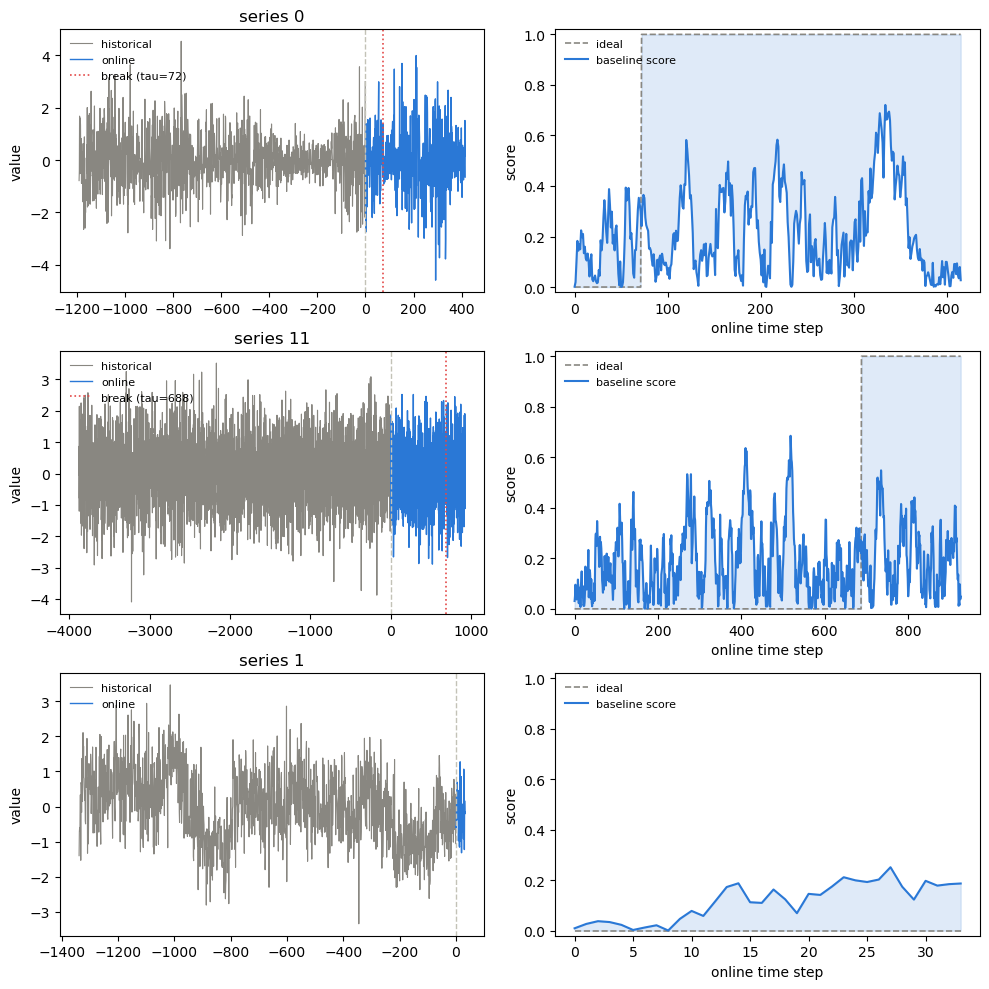

In [15]:
import matplotlib.pyplot as plt

# Pick a few contrasting series: an early break, a late break, and a no-break
# series, so you can see how the lag and the false-positive noise floor behave
# differently in each case.
picked = {"early_break": None, "late_break": None, "no_break": None}

for dataset_id, x_hist, x_online, tau in train_data:
    n_online = len(x_online)
    if tau is None and picked["no_break"] is None:
        picked["no_break"] = (dataset_id, x_hist, x_online, tau)
    elif tau is not None and tau <= 0.2 * n_online and picked["early_break"] is None:
        picked["early_break"] = (dataset_id, x_hist, x_online, tau)
    elif tau is not None and tau >= 0.7 * n_online and picked["late_break"] is None:
        picked["late_break"] = (dataset_id, x_hist, x_online, tau)
    if all(v is not None for v in picked.values()):
        break

fig, axes = plt.subplots(len(picked), 2, figsize=(10, 10))
for row, (name, (dataset_id, x_hist, x_online, tau)) in enumerate(picked.items()):
    x_hist = np.asarray(x_hist)
    x_online = np.asarray(x_online)
    scores = ewma_scores(x_hist, x_online)
    plot_series_and_score(dataset_id, x_hist, x_online, tau, scores, ax=axes[row])

plt.tight_layout()
plt.show()

## Ideas for stronger solutions

The baseline above is a starting point, not a competitive submission. <br />
Here are directions that typically pay off, in rough order of effort vs. expected benefit:

**Richer streaming statistics.** The EWMA reacts to *mean* shifts but ignores changes in variance, distributional shape, and serial correlation. Try maintaining, in parallel:

- A **CUSUM** of standardized residuals (cumulative deviation from the historical mean), which accumulates evidence over time rather than decaying it.
- Running **variance** and a ratio against $\sigma_H^2$ to catch volatility shifts.
- Fraction of online points beyond $\pm 2\sigma_H$ or $\pm 3\sigma_H$ (tail-mass change).
- Online **autocorrelation** at a few lags, compared to the historical autocorrelation.
- A **likelihood-ratio CUSUM** under a small autoregressive model fit to the historical segment.

All of these can be updated in O(1) per new observation with a bit of care.

**Combine features with a supervized model:**
- If you collect a handful of incremental features like the ones above into a vector, you have a standard tabular classification problem at every online step.
- A gradient boosting model (LightGBM, XGBoost) trained on `(feature_vector, label_t)` pairs from the training set can learn to weight the features much better than a hand-tuned rule.
- Remember to store *all* the state needed to reproduce the feature vector at inference time in O(1).

**Watch your time budget:**
- With 10,000 series and up to 1,000 online steps each, your code may be asked for up to 10 million scores.
- At any step, anything slower than a few microseconds of Python is a liability. Profile!

## Comparing EWMA vs. the KS test

Same three series as above, scored both ways side by side. Watch the KS-test
curve on any series where the break changes variance or shape without much
of a mean shift -- exactly the case the EWMA baseline can't see.

C:\Users\amank\AppData\Local\Temp\ipykernel_20332\2285385920.py:172: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\amank\AppData\Local\Temp\ipykernel_20332\821563936.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


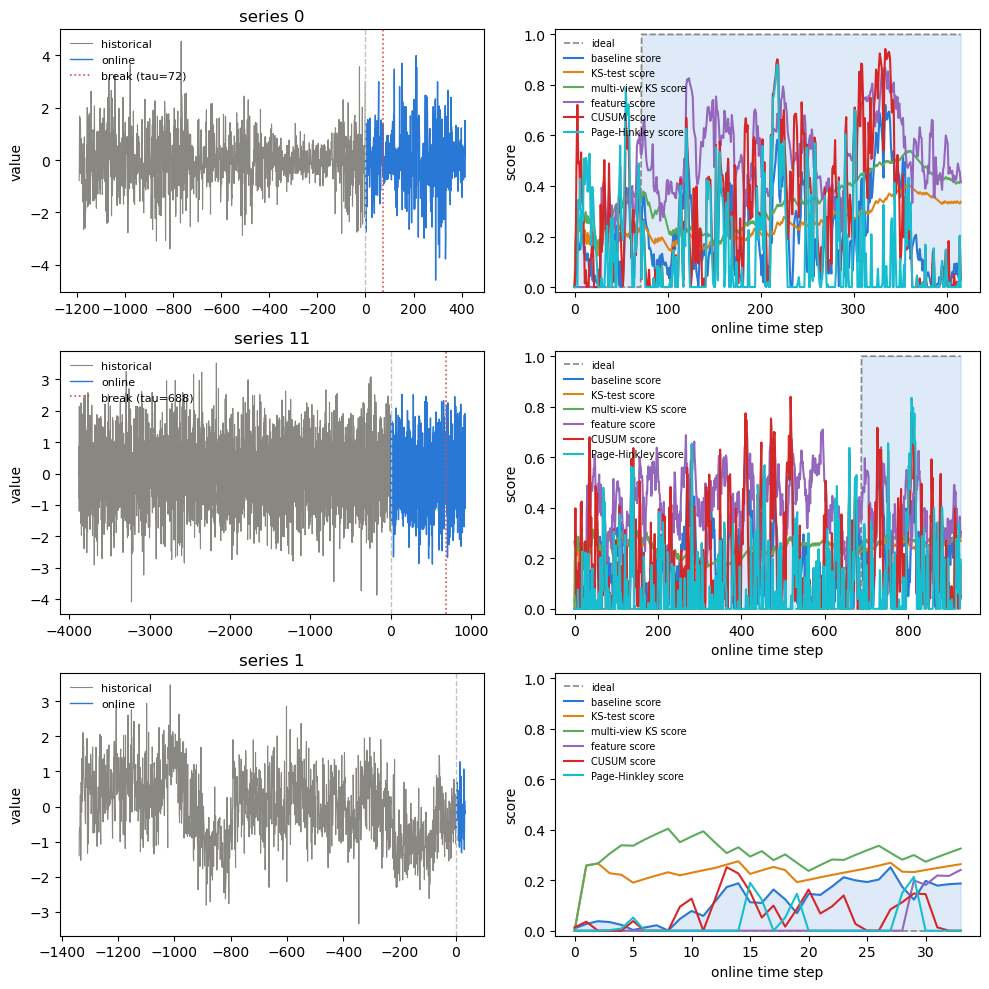

In [16]:
fig, axes = plt.subplots(len(picked), 2, figsize=(10, 10))
for row, (name, (dataset_id, x_hist, x_online, tau)) in enumerate(picked.items()):
    x_hist = np.asarray(x_hist)
    x_online = np.asarray(x_online)

    ewma_s = ewma_scores(x_hist, x_online)
    ks_s = ks_test_scores(x_hist, x_online)
    multi_s = multi_ks_scores(x_hist, x_online)
    feat_s = feature_scores(x_hist, x_online)
    cusum_s = cusum_scores(x_hist, x_online)
    ph_s = page_hinkley_scores(x_hist, x_online)

    ax_series, ax_score = plot_series_and_score(dataset_id, x_hist, x_online, tau, ewma_s, ax=axes[row])
    ax_score.plot(np.arange(len(x_online)), ks_s, color="#e08214", lw=1.5, label="KS-test score")
    ax_score.plot(np.arange(len(x_online)), multi_s, color="#5cab5c", lw=1.5, label="multi-view KS score")
    ax_score.plot(np.arange(len(x_online)), feat_s, color="#9467bd", lw=1.5, label="feature score")
    ax_score.plot(np.arange(len(x_online)), cusum_s, color="#d62728", lw=1.5, label="CUSUM score")
    ax_score.plot(np.arange(len(x_online)), ph_s, color="#17becf", lw=1.5, label="Page-Hinkley score")
    ax_score.legend(loc="upper left", fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

# Submitting your notebook

To submit your work, you must:

1. Download your notebook (from Colab, Kaggle, or a local copy).
2. Upload it to the competition platform.
3. Create a **run** to validate it against the full test set.

Executing the cell below will take care of everything (only available on Google Colab), or show you how to submit manually.

In [17]:
# @title  {"display-mode":"form", "form-width":"400px"}

# @markdown Describe your changes, then run the cell.
Message = "" # @param {"type":"string","placeholder":"Short description (optional)"}

# ---
# THIS METHOD IS ONLY POSSIBLE ON COLAB.
# RUNNING THIS CELL WILL PROMPT YOU TO USE THE OLD WAY OF SUBMITTING A NOTEBOOK.

crunch_tools.submit(
    message=Message,
)


---

Your work could not be submitted automatically, please do so manually:
1. Download your Notebook from Colab
2. Upload it to the platform
3. Create a run to validate it

### >> [https://hub.crunchdao.com/competitions/structural-break-real-time/submit/notebook](https://hub.crunchdao.com/competitions/structural-break-real-time/submit/notebook?projectName=alone-roundworm&message=)

<img alt="Download and Submit Notebook" src="https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/animations/download-and-submit-notebook.gif" height="600px" />

<br />
<small>Error preventing submit: <code>No module named 'google.colab'</code></small>
